# OCR and NLP with Scanned Documents

This notebook demonstrates a comprehensive pipeline for extracting and analyzing information from scanned documents. The pipeline combines OCR (Optical Character Recognition) to extract text from images and NLP (Natural Language Processing) tasks for advanced text analysis.

## Install Required Libraries

In [6]:
! pip install transformers datasets pytesseract pillow
!apt-get update
!apt-get install -y tesseract-ocr


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,615 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,646 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1

## Upload image

In [7]:
from google.colab import files

# Upload the image file
uploaded = files.upload()

# Get the file name
image_path = list(uploaded.keys())[0]
print(f"Uploaded file: {image_path}")


Saving expense1.png to expense1 (1).png
Uploaded file: expense1 (1).png


## Verify image

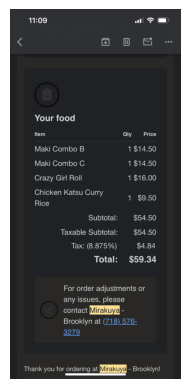

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Open and display the uploaded image
image = Image.open(image_path)
plt.imshow(image)
plt.axis("off")
plt.show()


## Extract Text from Scanned Documents

In [9]:
# Perform OCR with Tesseract
import pytesseract
extracted_text = pytesseract.image_to_string(image)
print("Extracted Text:\n", extracted_text)


Extracted Text:
 11:09 TBD

WS e-
Your food
Item (el oT
Maki Combo B 1 $14.50
Maki Combo C 1 $14.50
Crazy Girl Roll svn lone)0

ae Katsu Curry Peete
Subtotal: $54.50

Taxable Subtotal: $54.50

Tax: (8.875%) SY

Total: $59.34

For order adjustments or
any issues, please
erelaietealVirakuyale
Brooklyn at (718) 576-
3279

Thank you for ordering at - Brooklyn!



## Load a Pretrained NLP Model for Text Processing

In [11]:
from transformers import pipeline

# Load a summarization pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Summarize the extracted text
summary = summarizer(extracted_text, max_length=130, min_length=30, do_sample=False)
print("Summary:\n", summary[0]['summary_text'])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


Summary:
 Crazy Girl Roll: $14.50 for two. Katsu Curry Peete: $12.50. Maki Combo B: $13.50, C: $15, D: $16.


## Perform Named Entity Recognition (NER) - Optional

In [12]:
# Load an NER pipeline
ner_pipeline = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english", aggregation_strategy="simple")

# Perform NER on the extracted text
entities = ner_pipeline(extracted_text)
print("Named Entities:")
for entity in entities:
    print(f"Entity: {entity['word']}, Type: {entity['entity_group']}, Confidence: {entity['score']:.2f}")


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Device set to use cpu


Named Entities:
Entity: Ma, Type: MISC, Confidence: 0.36
Entity: Ma, Type: MISC, Confidence: 0.32
Entity: Girl, Type: MISC, Confidence: 0.75
Entity: Roll, Type: ORG, Confidence: 0.71
Entity: Katsu Curry Peete, Type: ORG, Confidence: 0.74
Entity: ##Virakuyale, Type: ORG, Confidence: 0.72
Entity: Brooklyn, Type: LOC, Confidence: 0.64
Entity: Brooklyn, Type: LOC, Confidence: 0.98


## Save or Process Results

In [13]:
# Save extracted text to a file
with open("extracted_text.txt", "w") as f:
    f.write(extracted_text)

# Save summary to a file
with open("summary.txt", "w") as f:
    f.write(summary[0]['summary_text'])


## Chain Tasks Together

In [19]:
from google.colab import files
from PIL import Image
import pytesseract
from transformers import pipeline

# Load Hugging Face pipelines
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
ner_pipeline = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english", aggregation_strategy="simple")

# Function to process scanned documents
def process_scanned_document(image_path):
    # Step 1: Perform OCR
    image = Image.open(image_path)
    extracted_text = pytesseract.image_to_string(image)

    # Step 2: Perform Summarization
    summary = summarizer(extracted_text, max_length=130, min_length=30, do_sample=False)[0]['summary_text']

    # Step 3: Perform NER
    entities = ner_pipeline(extracted_text)

    return {
        "extracted_text": extracted_text,
        "summary": summary,
        "entities": entities
    }

# Step to upload file
print("Please upload a scanned document image file:")
uploaded = files.upload()

# Get the uploaded file path
image_path = list(uploaded.keys())[0]

# Example usage
result = process_scanned_document(image_path)
print("Extracted Text:\n", result['extracted_text'])
print("\nSummary:\n", result['summary'])
print("\nNamed Entities:\n", result['entities'])


Device set to use cpu
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Please upload a scanned document image file:


Saving expense2.png to expense2 (1).png


Your max_length is set to 130, but your input_length is only 122. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)


Extracted Text:
 11:09 TBD

 

See
727 Flushing Ave
Brooklyn, NY 11206

Cady Berry, thank you for
your order!

Order #540081 70

Your - Brooklyn order will
be ready on Dec 20, 2024 @ 3:56
PM. If you need to change or cancel
your order, please call us at (718)
576-3279.

Order is for

Cady Berry
(860) 462-7172
acadiaberry@gmail.com

 


Summary:
 Your order will be ready on Dec 20, 2024 @ 3:56PM. If you need to change or cancel your order, please call us at (718) 462-7172.

Named Entities:
 [{'entity_group': 'LOC', 'score': 0.86070216, 'word': 'Flushing Ave Brooklyn', 'start': 22, 'end': 43}, {'entity_group': 'LOC', 'score': 0.7241589, 'word': 'NY', 'start': 45, 'end': 47}, {'entity_group': 'ORG', 'score': 0.9500019, 'word': 'Cady Berry', 'start': 55, 'end': 65}, {'entity_group': 'LOC', 'score': 0.99149317, 'word': 'Brooklyn', 'start': 119, 'end': 127}, {'entity_group': 'ORG', 'score': 0.93485665, 'word': 'Cady Berry', 'start': 268, 'end': 278}, {'entity_group': 'ORG', 'score': 0.56669